In [1]:
import pandas as pd
pumpkins = pd.read_csv('../data/US-pumpkins.csv')
pumpkins.head()
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case = True, regex=True)]

In [2]:
pumpkins.isnull().sum()

City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [4]:
columns_to_select = ['City Name', 'Low Price', 'High Price', 'Date','Package']
pumpkins = pumpkins.loc[:, columns_to_select]

price = (pumpkins['Low Price'] + pumpkins['High Price'])/2
month = pd.DatetimeIndex(pumpkins['Date']).month


In [5]:
new_pumpkins = pd.DataFrame({'City' : pumpkins['City Name'], 'Month': month, 'Price':price, 'Package' : pumpkins['Package'], 'Low Price' : pumpkins['Low Price'], 'High Price' : pumpkins['High Price']})

In [7]:
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/(1+1/9)
new_pumpkins.loc[new_pumpkins['Package'].str.contains(' 1/2'), 'Price'] = price/(1/2)

In [6]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Pumpkin Price')

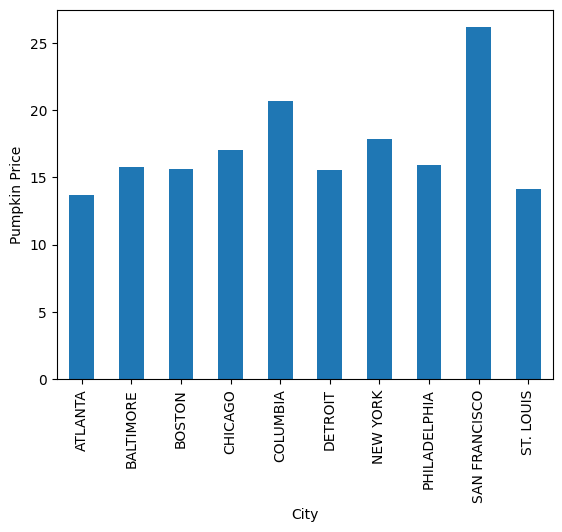

In [8]:
new_pumpkins.groupby(['City'])['Price'].mean().plot(kind='bar')
plt.ylabel("Pumpkin Price")